# Đánh Giá Hiệu Quả Promotions
# Luận điểm kiểm định: *"Chiến lược Promotions của Doanh nghiệp KHÔNG hiệu quả?"*

5 tiêu chí:
1. Promo có làm tăng Volume (số lượng bán)?
2. Promo có làm xấu Gross Profit?
3. Promo có làm tăng Return Rate quá mức?
4. Promo có giúp xả hàng tồn kho (overstock)?
5. Mật độ promo & tháng hiệu quả / kém hiệu quả nhất?

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import os

# 1. Thiết lập đường dẫn (dấu '.' nếu file nằm cùng thư mục với code)
path = '.' 

# 2. Lấy danh sách tất cả file kết thúc bằng .csv
files = [f for f in os.listdir(path) if f.endswith('.csv')]

# 3. Đọc tất cả vào một Dictionary
# Key là tên file (bỏ đuôi .csv), Value là nội dung bảng (DataFrame)
data = {f[:-4]: pd.read_csv(os.path.join(path, f)) for f in files}

# 4. Kiểm tra các bảng đã đọc được
print("Các bảng đã load thành công:", data.keys())

Các bảng đã load thành công: dict_keys(['customers', 'geography', 'inventory', 'orders', 'order_items', 'payments', 'products', 'promotions', 'returns', 'reviews', 'sales', 'sample_submission', 'shipments', 'web_traffic'])


In [7]:
# Đọc các bảng chính
customers   = pd.read_csv("customers.csv")
inventory   = pd.read_csv("inventory.csv")
orders      = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
products    = pd.read_csv("products.csv")
returns     = pd.read_csv("returns.csv")
shipments   = pd.read_csv("shipments.csv")

# Đọc các bảng bổ trợ
geography   = pd.read_csv("geography.csv")
payments    = pd.read_csv("payments.csv")
promotions  = pd.read_csv("promotions.csv")
reviews     = pd.read_csv("reviews.csv")
sales       = pd.read_csv("sales.csv")
web_traffic = pd.read_csv("web_traffic.csv")

# ── Standardize dates ────────────────────────────────────────────────────
orders["order_date"]        = pd.to_datetime(orders["order_date"])
promotions["start_date"]    = pd.to_datetime(promotions["start_date"])
promotions["end_date"]      = pd.to_datetime(promotions["end_date"])
inventory["snapshot_date"]  = pd.to_datetime(inventory["snapshot_date"])
returns["return_date"]      = pd.to_datetime(returns["return_date"])

# ── Master join: order_items + orders + products ─────────────────────────
df = (order_items
      .merge(orders[["order_id","order_date","customer_id","order_status"]],
             on="order_id", how="left")
      .merge(products[["product_id","product_name","category","segment","price","cogs"]],
             on="product_id", how="left"))

# ── Flag promo order (via promo_id in order_items) ───────────────────────
promo_col = next((c for c in df.columns if "promo" in c.lower()), None)
print(f"Promo column detected: {promo_col}")

if promo_col:
    df["is_promo"] = (
        df[promo_col].notna() &
        (~df[promo_col].astype(str).str.strip().isin(["","0","nan","None"]))
    )
else:
    # Fallback: flag by date range
    intervals = list(zip(promotions["start_date"], promotions["end_date"]))
    df["is_promo"] = df["order_date"].apply(
        lambda d: any(s <= d <= e for s, e in intervals)
    )

df["promo_label"] = df["is_promo"].map({True:"Co Promo", False:"Khong Promo"})

# ── Financial KPIs ───────────────────────────────────────────────────────
df["revenue"]      = df["quantity"] * df["unit_price"]
df["discount"]     = df["discount_amount"].fillna(0)
df["net_revenue"]  = df["revenue"] - df["discount"]
df["gross_profit"] = df["net_revenue"] - df["quantity"] * df["cogs"].fillna(0)
df["gp_margin"]    = df["gross_profit"] / df["net_revenue"].replace(0, np.nan)

print(f"Total rows: {len(df):,}")
print(f"Promo orders: {df['is_promo'].sum():,} ({df['is_promo'].mean()*100:.1f}%)")
print()
print(df.groupby("promo_label")[["revenue","net_revenue","gross_profit","quantity"]].sum().round(2))

Promo column detected: promo_id
Total rows: 714,669
Promo orders: 276,316 (38.7%)

                  revenue   net_revenue  gross_profit  quantity
promo_label                                                    
Co Promo     5.435438e+09  4.685830e+09 -6.775966e+08   1242039
Khong Promo  1.099504e+10  1.099504e+10  2.195015e+09   1971104


---
## Tiêu Chí 1: Promo có làm tăng Volume không?
> So sánh số lượng bán trung bình / ngày trong vs ngoài thời gian promo

=== Volume & Revenue trung binh / ngay ===
Co Promo    - Units/ngay: 719.2  |  Revenue/ngay: 2,713,277
Khong Promo - Units/ngay: 935.9  |  Revenue/ngay: 5,220,816


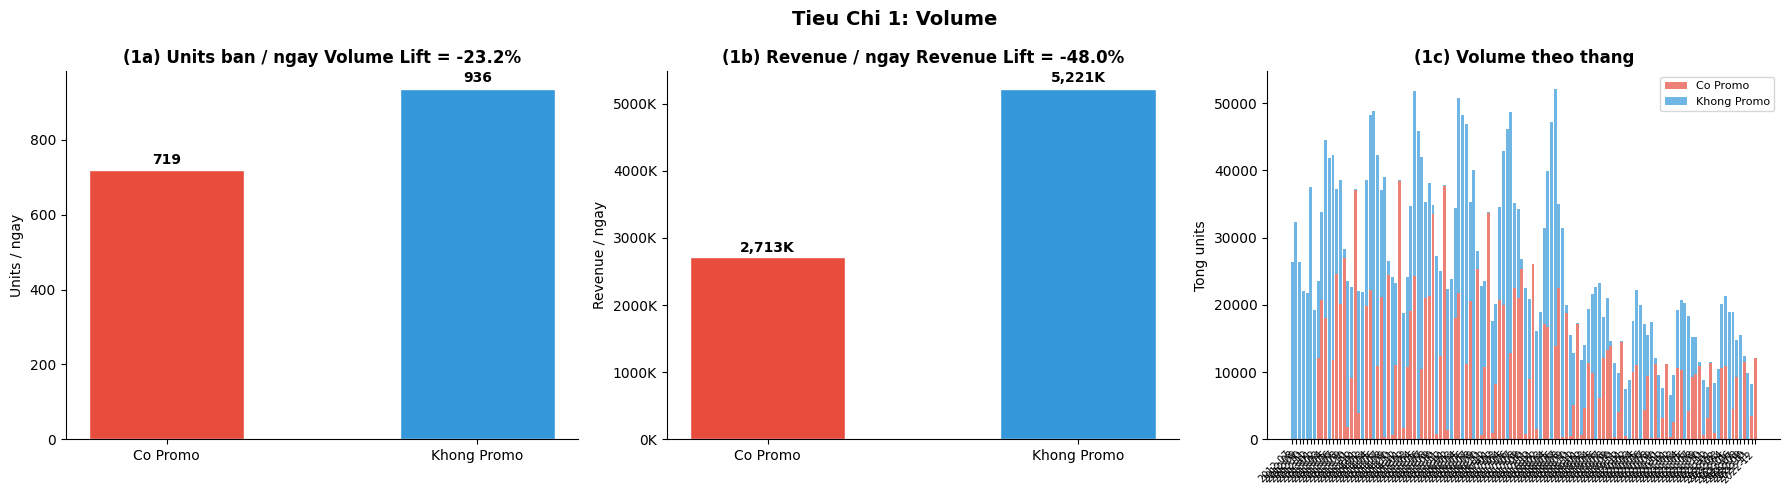


KET LUAN TIEU CHI 1: VOLUME
[FAIL] FAIL - Promo KHONG tang volume (-23.2%/ngay)


In [8]:
# Tính số ngày promo và non-promo
promo_days = int((promotions["end_date"] - promotions["start_date"]).dt.days.sum() + len(promotions))
total_days  = int((orders["order_date"].max() - orders["order_date"].min()).days) + 1
non_promo_days = max(total_days - promo_days, 1)

vol = df.groupby("promo_label")["quantity"].sum()
rev = df.groupby("promo_label")["net_revenue"].sum()

vol_per_day = pd.Series({
    "Co Promo"    : vol.get("Co Promo", 0)    / promo_days,
    "Khong Promo" : vol.get("Khong Promo", 0) / non_promo_days,
})
rev_per_day = pd.Series({
    "Co Promo"    : rev.get("Co Promo", 0)    / promo_days,
    "Khong Promo" : rev.get("Khong Promo", 0) / non_promo_days,
})

print("=== Volume & Revenue trung binh / ngay ===")
print(f"Co Promo    - Units/ngay: {vol_per_day['Co Promo']:,.1f}  |  Revenue/ngay: {rev_per_day['Co Promo']:,.0f}")
print(f"Khong Promo - Units/ngay: {vol_per_day['Khong Promo']:,.1f}  |  Revenue/ngay: {rev_per_day['Khong Promo']:,.0f}")

vol_lift = (vol_per_day["Co Promo"] / vol_per_day["Khong Promo"] - 1) * 100
rev_lift = (rev_per_day["Co Promo"] / rev_per_day["Khong Promo"] - 1) * 100

# Monthly volume: promo months vs non-promo months
df["ym"] = df["order_date"].dt.to_period("M")
monthly_vol = df.groupby(["ym","promo_label"])["quantity"].sum().unstack(fill_value=0).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Tieu Chi 1: Volume", fontsize=14, fontweight="bold")

# Bar: units/day
colors = ["#E74C3C","#3498DB"]
bars = axes[0].bar(vol_per_day.index, vol_per_day.values, color=colors, width=0.5, edgecolor="white")
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                 f"{bar.get_height():,.0f}", ha="center", va="bottom", fontweight="bold")
axes[0].set_title(f"(1a) Units ban / ngay Volume Lift = {vol_lift:+.1f}%", fontweight="bold")
axes[0].set_ylabel("Units / ngay")
axes[0].spines["top"].set_visible(False); axes[0].spines["right"].set_visible(False)

# Bar: revenue/day
bars2 = axes[1].bar(rev_per_day.index, rev_per_day.values, color=colors, width=0.5, edgecolor="white")
for bar in bars2:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                 f"{bar.get_height()/1e3:,.0f}K", ha="center", va="bottom", fontweight="bold")
axes[1].set_title(f"(1b) Revenue / ngay Revenue Lift = {rev_lift:+.1f}%", fontweight="bold")
axes[1].set_ylabel("Revenue / ngay")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e3:.0f}K"))
axes[1].spines["top"].set_visible(False); axes[1].spines["right"].set_visible(False)

# Line: monthly volume trend
ax3 = axes[2]
if "Co Promo" in monthly_vol.columns:
    ax3.bar(range(len(monthly_vol)), monthly_vol["Co Promo"],
            label="Co Promo", color="#E74C3C", alpha=0.7)
if "Khong Promo" in monthly_vol.columns:
    ax3.bar(range(len(monthly_vol)), monthly_vol["Khong Promo"],
            bottom=monthly_vol.get("Co Promo",0), label="Khong Promo", color="#3498DB", alpha=0.7)
ax3.set_xticks(range(len(monthly_vol)))
ax3.set_xticklabels([str(p) for p in monthly_vol["ym"]], rotation=45, ha="right", fontsize=7)
ax3.set_title("(1c) Volume theo thang", fontweight="bold")
ax3.set_ylabel("Tong units")
ax3.legend(fontsize=8)
ax3.spines["top"].set_visible(False); ax3.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# ── KẾT LUẬN 1 ───────────────────────────────────────────────────────────
print()
print("=" * 55)
print("KET LUAN TIEU CHI 1: VOLUME")
print("=" * 55)
if vol_lift > 10:
    kl1 = f"PASS - Promo tang volume ro ret ({vol_lift:+.1f}%/ngay)"; icon1 = "[PASS]"
elif vol_lift > 0:
    kl1 = f"CANH BAO - Volume tang nhe ({vol_lift:+.1f}%), chua du manh"; icon1 = "[WARN]"
else:
    kl1 = f"FAIL - Promo KHONG tang volume ({vol_lift:+.1f}%/ngay)"; icon1 = "[FAIL]"
print(f"{icon1} {kl1}")

---
## Tiêu Chí 2: Promo có làm xấu Gross Profit không?
> So sánh GP margin, tổng GP, và GP/đơn hàng

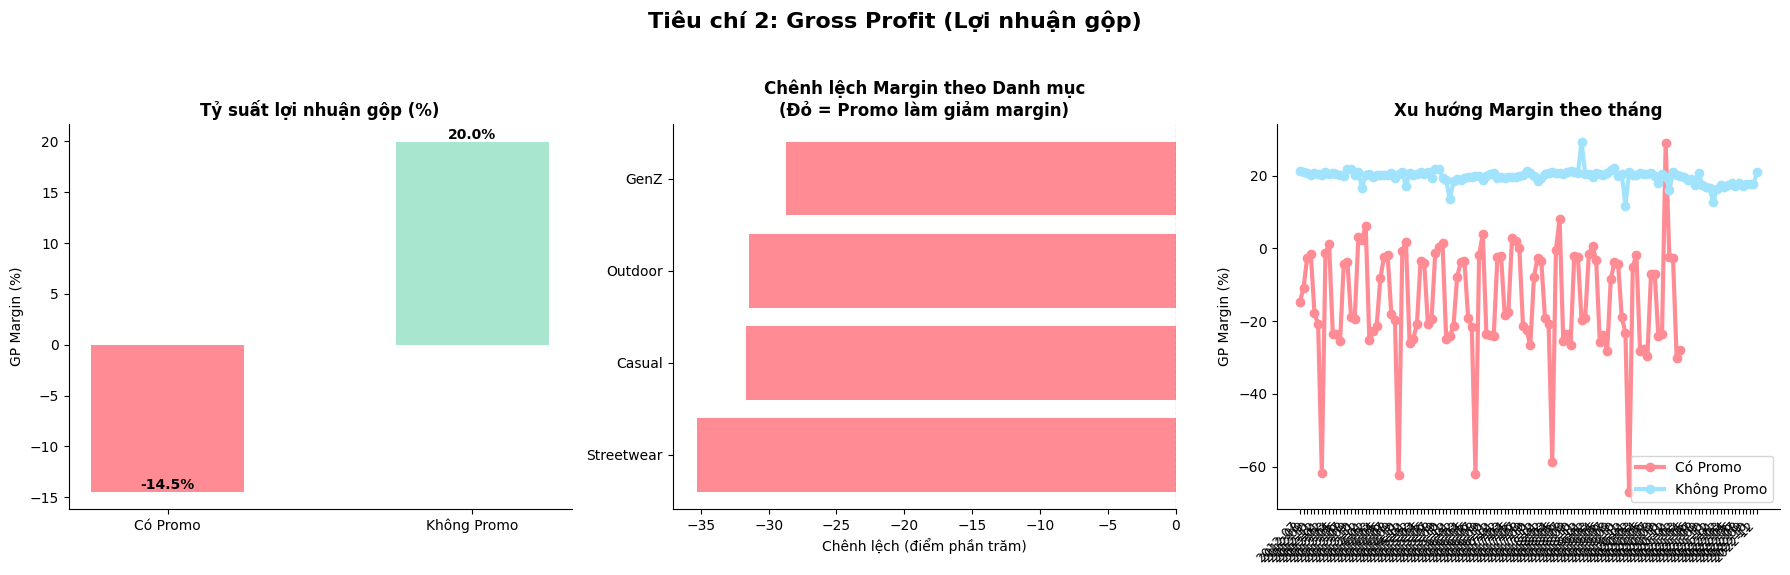


KẾT LUẬN TIÊU CHÍ 2: GROSS PROFIT (LỢI NHUẬN GỘP)
[FAIL] THẤT BẠI: Promo làm tỷ suất lợi nhuận gộp giảm mạnh (-34.4 điểm phần trăm)

KET LUAN TIEU CHI 2: GROSS PROFIT
[FAIL] FAIL - Promo lam GP margin giam manh (-34.4 pp)


In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Cấu hình màu sắc Pastel nguyên bản ---
green_pastel = "#A8E6CF"
red_pastel = "#FF8B94"
blue_pastel = "#A1E3FC"

# --- Tiền xử lý và Tính toán (Giữ nguyên logic của bạn) ---
gp = df.groupby("promo_label").agg(
    tong_gross_profit = ("gross_profit", "sum"),
    tong_net_revenue  = ("net_revenue",  "sum"),
    tong_discount     = ("discount",     "sum"),
    so_don            = ("order_id",     "nunique"),
    so_units          = ("quantity",     "sum"),
).round(2)

# Chuyển đổi index sang tiếng Việt có dấu để hiển thị đồng nhất
gp.index = gp.index.map({"Co Promo": "Có Promo", "Khong Promo": "Không Promo"})

gp["gp_margin_%"]   = (gp["tong_gross_profit"] / gp["tong_net_revenue"] * 100).round(2)
gp["gp_per_don"]    = (gp["tong_gross_profit"] / gp["so_don"]).round(2)
gp["discount_rate"] = (gp["tong_discount"] / (gp["tong_net_revenue"] + gp["tong_discount"]) * 100).round(2)

# GP theo category x promo
gp_cat = df.groupby(["category","promo_label"]).agg(
    gp     = ("gross_profit","sum"),
    rev    = ("net_revenue", "sum"),
).reset_index()
gp_cat["promo_label"] = gp_cat["promo_label"].map({"Co Promo": "Có Promo", "Khong Promo": "Không Promo"})
gp_cat["margin"] = gp_cat["gp"] / gp_cat["rev"] * 100

gp_pivot = gp_cat.pivot_table(index="category", columns="promo_label", values="margin").fillna(0)
gp_pivot["margin_diff"] = gp_pivot.get("Có Promo", 0) - gp_pivot.get("Không Promo", 0)

# Monthly GP margin trend
monthly_gp = df.groupby(["ym","promo_label"]).agg(
    gp  = ("gross_profit","sum"),
    rev = ("net_revenue", "sum"),
).reset_index()
monthly_gp["promo_label"] = monthly_gp["promo_label"].map({"Co Promo": "Có Promo", "Khong Promo": "Không Promo"})
monthly_gp["margin"] = monthly_gp["gp"] / monthly_gp["rev"] * 100

# --- Vẽ biểu đồ ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Tiêu chí 2: Gross Profit (Lợi nhuận gộp)", fontsize=16, fontweight="bold")

# (2a) GP Margin % (Màu Đỏ hồng cho Có Promo, Xanh lá cho Không Promo)
ax = axes[0]
gp_m = gp["gp_margin_%"]
bars = ax.bar(gp_m.index, gp_m.values, color=[red_pastel, green_pastel], width=0.5, edgecolor="none")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontweight="bold")
ax.set_title("Tỷ suất lợi nhuận gộp (%)", fontweight="bold")
ax.set_ylabel("GP Margin (%)")
ax.spines[["top", "right"]].set_visible(False)

# (2b) Margin Diff theo Category (Xanh lá nếu tăng margin, Đỏ hồng nếu giảm)
ax = axes[1]
mdiff = gp_pivot["margin_diff"].sort_values()
bar_c = [red_pastel if v < 0 else green_pastel for v in mdiff]
ax.barh(mdiff.index, mdiff.values, color=bar_c, edgecolor="none")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Chênh lệch Margin theo Danh mục\n(Đỏ = Promo làm giảm margin)", fontweight="bold")
ax.set_xlabel("Chênh lệch (điểm phần trăm)")
ax.spines[["top", "right"]].set_visible(False)

# (2c) GP Margin trend theo tháng
ax = axes[2]
for label, grp in monthly_gp.groupby("promo_label"):
    grp_s = grp.sort_values("ym")
    ax.plot(range(len(grp_s)), grp_s["margin"],
            label=label, linewidth=3,
            color=red_pastel if label == "Có Promo" else blue_pastel,
            marker="o", markersize=6)
ax.set_xticks(range(len(grp_s)))
ax.set_xticklabels([str(p) for p in grp_s["ym"]], rotation=45, ha="right", fontsize=9)
ax.set_title("Xu hướng Margin theo tháng", fontweight="bold")
ax.set_ylabel("GP Margin (%)")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Kết luận với tiếng Việt có dấu ---
margin_promo    = gp.loc["Có Promo",    "gp_margin_%"] if "Có Promo" in gp.index else 0
margin_no_promo = gp.loc["Không Promo", "gp_margin_%"] if "Không Promo" in gp.index else 0
margin_drop = margin_promo - margin_no_promo

print("\n" + "=" * 60)
print("KẾT LUẬN TIÊU CHÍ 2: GROSS PROFIT (LỢI NHUẬN GỘP)")
print("=" * 60)

if margin_drop < -5:
    status = "THẤT BẠI"
    kl2 = f"Promo làm tỷ suất lợi nhuận gộp giảm mạnh ({margin_drop:+.1f} điểm phần trăm)"
    icon2 = "[FAIL]"
elif margin_drop < 0:
    status = "CẢNH BÁO"
    kl2 = f"Tỷ suất lợi nhuận gộp giảm nhẹ ({margin_drop:+.1f} điểm phần trăm) - cần kiểm tra độ sâu chiết khấu"
    icon2 = "[WARN]"
else:
    status = "THÀNH CÔNG"
    kl2 = f"Tỷ suất lợi nhuận gộp không bị ảnh hưởng xấu ({margin_drop:+.1f} điểm phần trăm)"
    icon2 = "[PASS]"

print(f"{icon2} {status}: {kl2}")

print()
print("=" * 55)
print("KET LUAN TIEU CHI 2: GROSS PROFIT")
print("=" * 55)
if margin_drop < -5:
    kl2 = f"FAIL - Promo lam GP margin giam manh ({margin_drop:+.1f} pp)"; icon2="[FAIL]"
elif margin_drop < 0:
    kl2 = f"CANH BAO - GP margin giam nhe ({margin_drop:+.1f} pp) - can kiem tra discount depth"; icon2="[WARN]"
else:
    kl2 = f"PASS - GP margin khong bi anh huong xau ({margin_drop:+.1f} pp)"; icon2="[PASS]"
print(f"{icon2} {kl2}")

In [10]:
# ============================================================
# PHÂN TÍCH TOÀN DIỆN: TẠI SAO PROMO KHÔNG HIỆU QUẢ?
# 5 Giả thuyết cần kiểm tra:
#   GT1: Discount quá cao, volume tăng không bù được margin
#   GT2: Promo nhắm sai sản phẩm (chất lượng thấp - reviews)
#   GT3: Promo bị stack (promo_id + promo_id_2)
#   GT4: Hàng promo bị hoàn trả nhiều hơn (returns)
#   GT5: Promo kéo traffic nhưng không convert (web_traffic)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# --- Load tất cả bảng ---
order_items = pd.read_csv("order_items.csv")
orders      = pd.read_csv("orders.csv")
products    = pd.read_csv("products.csv")
promotions  = pd.read_csv("promotions.csv")
returns     = pd.read_csv("returns.csv")
reviews     = pd.read_csv("reviews.csv")
web_traffic = pd.read_csv("web_traffic.csv")
inventory   = pd.read_csv("inventory.csv")

# Chuẩn hóa tên cột
for d in [order_items, orders, products, promotions,
          returns, reviews, web_traffic, inventory]:
    d.columns = d.columns.str.lower().str.strip().str.replace(" ", "_")

print("=== DATA LOADED ===")
for name, d in [("order_items", order_items), ("orders", orders),
                ("products", products), ("promotions", promotions),
                ("returns", returns), ("reviews", reviews),
                ("web_traffic", web_traffic), ("inventory", inventory)]:
    print(f"  {name:12s}: {d.shape}  | cols: {d.columns.tolist()}")

# --- Base calculations (dùng chung cho tất cả GT) ---
qty   = order_items["quantity"].fillna(1)
price = order_items["unit_price"].fillna(0)
disc  = order_items["discount_amount"].fillna(0) if "discount_amount" in order_items.columns else pd.Series(0, index=order_items.index)
cogs_map = products.set_index("product_id")["cogs"].to_dict()

order_items["net_revenue"]  = qty * price - disc
order_items["cogs_val"]     = qty * order_items["product_id"].map(cogs_map).fillna(0)
order_items["gross_profit"] = order_items["net_revenue"] - order_items["cogs_val"]
order_items["discount_pct"] = (disc / (qty * price).replace(0, np.nan) * 100).round(2)

# Gắn nhãn promo
order_items["has_promo1"] = (
    order_items["promo_id"].notna() &
    (~order_items["promo_id"].astype(str).str.strip().isin(["", "0", "nan"]))
)
order_items["has_promo2"] = (
    order_items["promo_id_2"].notna() &
    (~order_items["promo_id_2"].astype(str).str.strip().isin(["", "0", "nan"]))
) if "promo_id_2" in order_items.columns else False

order_items["is_promo"]    = order_items["has_promo1"] | order_items["has_promo2"]
order_items["is_stacked"]  = order_items["has_promo1"] & order_items["has_promo2"]
order_items["promo_label"] = order_items["is_promo"].map({True: "Co Promo", False: "Khong Promo"})

print(f"\nTong don hang     : {len(order_items):,}")
print(f"Don co promo      : {order_items['is_promo'].sum():,} ({order_items['is_promo'].mean()*100:.1f}%)")
print(f"Don stack 2 promo : {order_items['is_stacked'].sum():,} ({order_items['is_stacked'].mean()*100:.1f}%)")
print("\n>>> Setup hoan tat! Chay cac cell tiep theo.")


=== DATA LOADED ===
  order_items : (714669, 7)  | cols: ['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2']
  orders      : (646945, 8)  | cols: ['order_id', 'order_date', 'customer_id', 'zip', 'order_status', 'payment_method', 'device_type', 'order_source']
  products    : (2412, 8)  | cols: ['product_id', 'product_name', 'category', 'segment', 'size', 'color', 'price', 'cogs']
  promotions  : (50, 10)  | cols: ['promo_id', 'promo_name', 'promo_type', 'discount_value', 'start_date', 'end_date', 'applicable_category', 'promo_channel', 'stackable_flag', 'min_order_value']
  returns     : (39939, 7)  | cols: ['return_id', 'order_id', 'product_id', 'return_date', 'return_reason', 'return_quantity', 'refund_amount']
  reviews     : (113551, 7)  | cols: ['review_id', 'order_id', 'product_id', 'customer_id', 'review_date', 'rating', 'review_title']
  web_traffic : (3652, 7)  | cols: ['date', 'sessions', 'unique_visitors', 'page_views', 'bounce_r

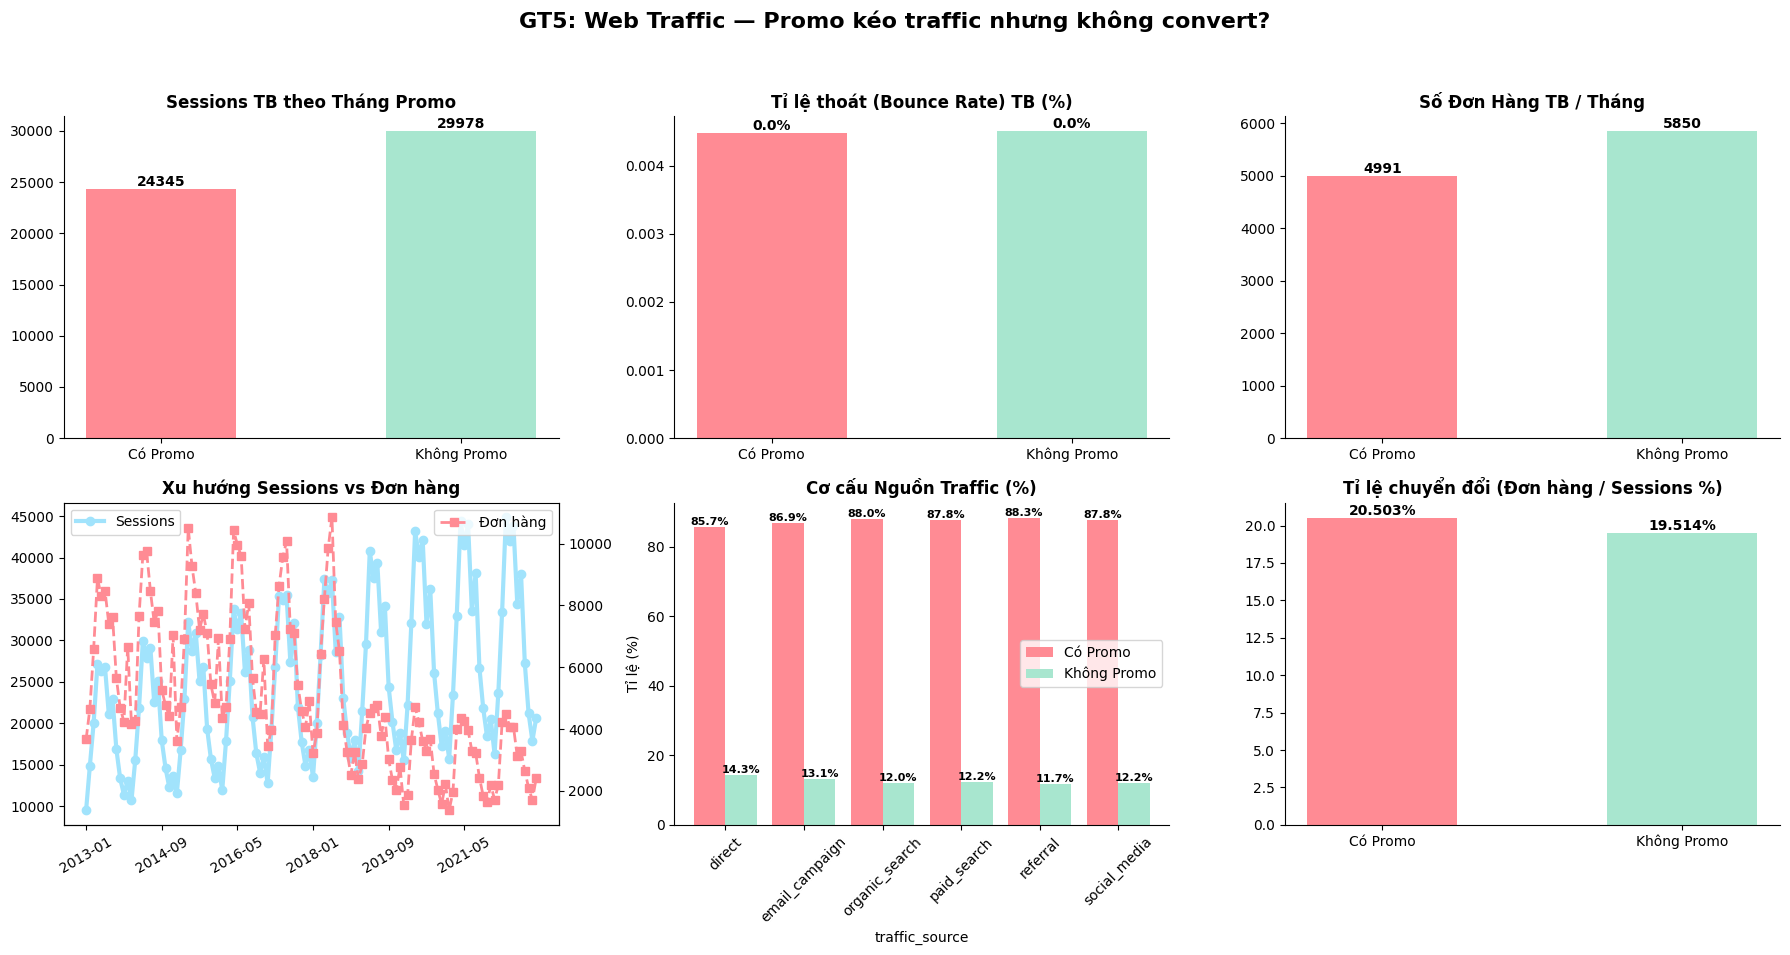

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# --- 1. Cấu hình màu sắc Pastel nguyên bản ---
green_pastel = "#A8E6CF"
red_pastel = "#FF8B94"
blue_pastel = "#A1E3FC"
# Gán màu theo nhóm để thống nhất
color_map = {"Có Promo": red_pastel, "Không Promo": green_pastel}

# --- Tiền xử lý dữ liệu (Giữ nguyên logic của bạn) ---
web_traffic["date"] = pd.to_datetime(web_traffic["date"], errors="coerce")
web_traffic["month"] = web_traffic["date"].dt.to_period("M")

for col in ["sessions", "bounce_rate", "n_orders"]:
    if col in web_traffic.columns:
        web_traffic[col] = pd.to_numeric(web_traffic[col], errors='coerce')

promo_months_set = set()
for _, row in promotions.iterrows():
    if pd.notna(row["start_date"]) and pd.notna(row["end_date"]):
        dr = pd.date_range(start=pd.to_datetime(row["start_date"]).replace(day=1),
                           end=pd.to_datetime(row["end_date"]), freq="MS")
        for d in dr:
            promo_months_set.add(d.to_period("M"))

web_traffic["has_promo_month"] = web_traffic["month"].isin(promo_months_set)
web_traffic["promo_label"] = web_traffic["has_promo_month"].map({True: "Có Promo", False: "Không Promo"})

orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")
orders["month"] = orders["order_date"].dt.to_period("M")
monthly_orders = orders.groupby("month").agg(n_orders=("order_id", "count")).reset_index()
monthly_orders["has_promo_month"] = monthly_orders["month"].isin(promo_months_set)
monthly_orders["promo_label"] = monthly_orders["has_promo_month"].map({True: "Có Promo", False: "Không Promo"})

# --- Vẽ biểu đồ ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plt.subplots_adjust(top=0.9, hspace=0.4) 
fig.suptitle("GT5: Web Traffic — Promo kéo traffic nhưng không convert?", fontsize=16, fontweight="bold")

# Hàm hỗ trợ thêm nhãn dữ liệu
def add_labels(ax, bars, is_pct=False, precision=0):
    for bar in bars:
        height = bar.get_height()
        label = f"{height:.{precision}f}" + ("%" if is_pct else "")
        ax.text(bar.get_x() + bar.get_width()/2, height, label, 
                ha="center", va="bottom", fontweight="bold", fontsize=10)

# --- 5a. Sessions TB ---
ax = axes[0, 0]
if "sessions" in web_traffic.columns:
    sess = web_traffic.groupby("promo_label")["sessions"].mean().reindex(["Có Promo", "Không Promo"]).fillna(0)
    bars = ax.bar(sess.index, sess.values, color=[red_pastel, green_pastel], width=0.5, edgecolor="none")
    ax.set_title("Sessions TB theo Tháng Promo", fontweight="bold")
    add_labels(ax, bars)
ax.spines[["top", "right"]].set_visible(False)

# --- 5b. Bounce rate TB (%) ---
ax = axes[0, 1]
if "bounce_rate" in web_traffic.columns:
    bounce = web_traffic.groupby("promo_label")["bounce_rate"].mean().reindex(["Có Promo", "Không Promo"]).fillna(0)
    bars = ax.bar(bounce.index, bounce.values, color=[red_pastel, green_pastel], width=0.5, edgecolor="none")
    ax.set_title("Tỉ lệ thoát (Bounce Rate) TB (%)", fontweight="bold")
    add_labels(ax, bars, is_pct=True, precision=1)
ax.spines[["top", "right"]].set_visible(False)

# --- 5c. Đơn hàng TB / Tháng ---
ax = axes[0, 2]
orders_avg = monthly_orders.groupby("promo_label")["n_orders"].mean().reindex(["Có Promo", "Không Promo"]).fillna(0)
bars = ax.bar(orders_avg.index, orders_avg.values, color=[red_pastel, green_pastel], width=0.5, edgecolor="none")
ax.set_title("Số Đơn Hàng TB / Tháng", fontweight="bold")
add_labels(ax, bars)
ax.spines[["top", "right"]].set_visible(False)

# --- 5d. Xu hướng Sessions vs Đơn hàng ---
ax = axes[1, 0]
m_sess = web_traffic.groupby("month")["sessions"].mean().reset_index()
m_sess["month_str"] = m_sess["month"].astype(str)
m_ord = monthly_orders[["month", "n_orders"]].copy()
m_ord["month_str"] = m_ord["month"].astype(str)
merged = pd.merge(m_sess, m_ord, on="month_str", how="inner")

if not merged.empty:
    ax2 = ax.twinx()
    ax.plot(merged["month_str"], merged["sessions"], color=blue_pastel, marker='o', label="Sessions", linewidth=3)
    ax2.plot(merged["month_str"], merged["n_orders"], color=red_pastel, marker='s', label="Đơn hàng", linestyle="--", linewidth=2)
    ax.set_title("Xu hướng Sessions vs Đơn hàng", fontweight="bold")
    ax.set_xticks(range(0, len(merged), max(1, len(merged)//6)))
    ax.tick_params(axis='x', rotation=30)
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")
ax.spines["top"].set_visible(False)

# --- 5e. Cơ cấu Nguồn Traffic (%) ---
ax = axes[1, 1]
if "traffic_source" in web_traffic.columns:
    src = web_traffic.groupby(["traffic_source", "promo_label"]).size().unstack(fill_value=0)
    src_pct = src.div(src.sum(axis=1), axis=0) * 100
    # Đảm bảo thứ tự hiển thị của Legend đồng nhất
    src_pct = src_pct[["Có Promo", "Không Promo"]]
    
    src_pct.plot(kind="bar", ax=ax, color=[red_pastel, green_pastel], edgecolor="none", width=0.8)
    ax.set_title("Cơ cấu Nguồn Traffic (%)", fontweight="bold")
    ax.set_ylabel("Tỉ lệ (%)")
    ax.tick_params(axis='x', rotation=45)
    
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f"{p.get_height():.1f}%", 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.legend(title="")
ax.spines[["top", "right"]].set_visible(False)

# --- 5f. Tỉ lệ chuyển đổi (%) ---
ax = axes[1, 2]
if "sessions" in web_traffic.columns:
    # Lấy sess đã tính ở trên (đúng thứ tự nhãn)
    cr = (orders_avg / sess * 100).fillna(0)
    bars = ax.bar(cr.index, cr.values, color=[red_pastel, green_pastel], width=0.5, edgecolor="none")
    ax.set_title("Tỉ lệ chuyển đổi (Đơn hàng / Sessions %)", fontweight="bold")
    # Tỉ lệ chuyển đổi thường nhỏ nên dùng 3 chữ số thập phân
    add_labels(ax, bars, is_pct=True, precision=3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

---
## 🏭 Tiêu Chí 4: Promo có giúp xả hàng tồn kho không?
> So sánh overstock_flag, days_of_supply, sell_through_rate trong vs ngoài promo period

            tong_von_chon  avg_stock_on_hand  avg_sell_through  n_snapshots
category_x                                                                 
Streetwear   3.255224e+10             236.94              0.09        23242
Outdoor      7.879571e+09             273.49              0.08        16809
Casual       1.086290e+09             116.48              0.10         2543
GenZ         8.212938e+08             167.49              0.09         3348

=== TOP 15 SẢN PHẨM CHÔN VỐN NHIỀU NHẤT ===
   product_name_x category_x  tong_von_chon  avg_stock  avg_sell_through  avg_days_supply
HanoiStreet UM-10 Streetwear   2.059782e+09    1362.53              0.06          1016.10
 SaigonFlex UM-92 Streetwear   1.021668e+09    1544.08              0.08          4889.01
    UrbanVN UE-14 Streetwear   8.926773e+08    1098.17              0.06          2057.91
 SaigonFlex UC-69 Streetwear   8.563379e+08    1680.88              0.06          2551.86
HanoiStreet UE-36 Streetwear   8.294121e+08    13

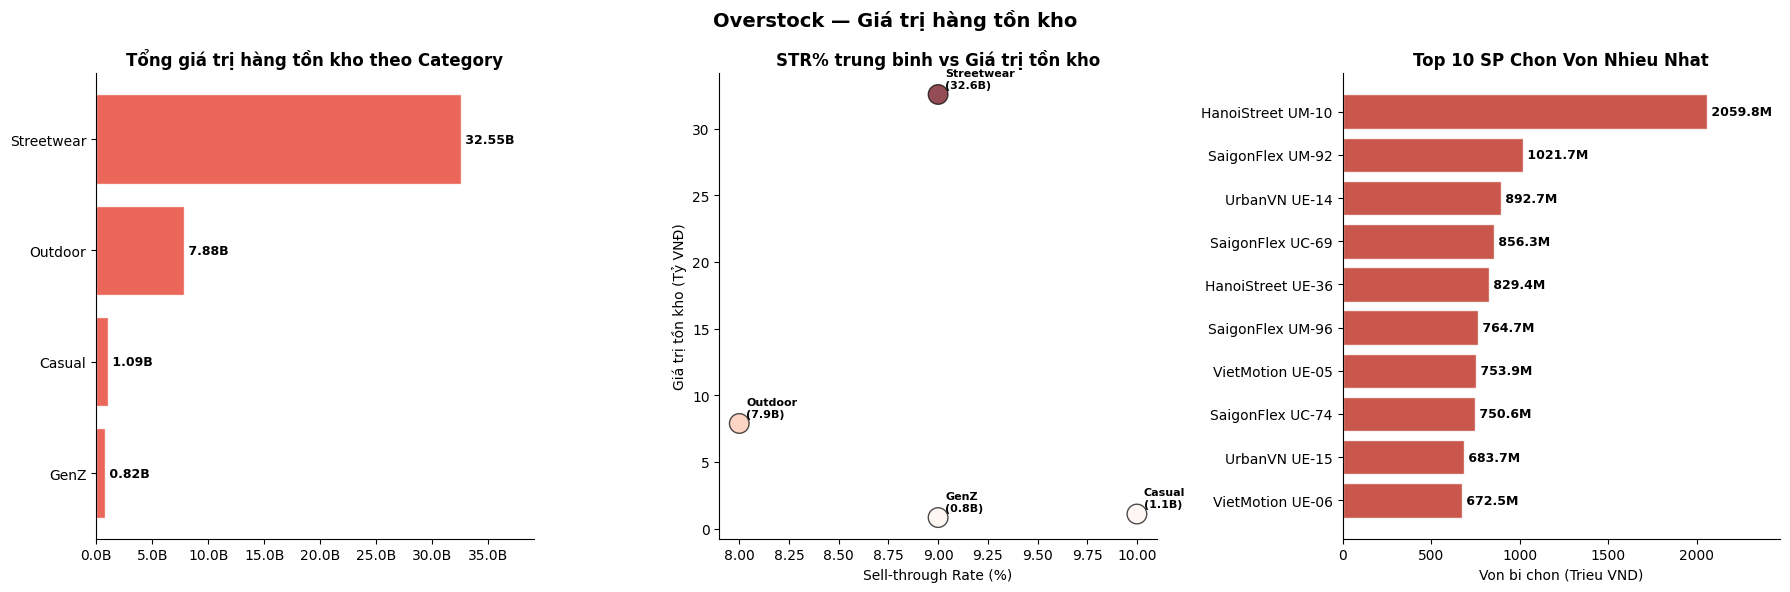

Tong von bi chon (tat ca overstock): 42,339,396,895 VND
Category chon nhieu nhat: 32,552,242,382 VND (Streetwear)
Category sell-through thap nhat: 8.0% (Outdoor)


In [ ]:
# TIER 1 - #2: OVERSTOCK → VỐN BỊ CHÔN TRONG KHO
# Vốn bị chôn = stock_on_hand × cogs

inventory = pd.read_csv("inventory.csv")
products  = pd.read_csv("products.csv")

inv = inventory.merge(products[["product_id","product_name","category","segment","cogs"]], on="product_id", how="left")
inv["capital_locked"] = inv["stock_on_hand"] * inv["cogs"]

overstock = inv[inv["overstock_flag"] == 1]

if 'category' not in overstock.columns and overstock.index.name == 'category':
    df_temp = overstock.reset_index()
else:
    df_temp = overstock.copy()

category_col = "category_x" if "category_x" in df_temp.columns else "category"
if category_col not in df_temp.columns:
    raise KeyError(f"Khong tim thay cot category. Cac cot hien co: {df_temp.columns.tolist()}")

cat_locked = df_temp.groupby(category_col).agg(
    tong_von_chon     = ("capital_locked",   "sum"),
    avg_stock_on_hand = ("stock_on_hand",    "mean"),
    avg_sell_through  = ("sell_through_rate","mean"),
    n_snapshots       = ("product_id",       "count"),
).round(2).sort_values("tong_von_chon", ascending=False)

print(cat_locked)

top_locked = overstock.groupby(["product_id","product_name_x","category_x"]).agg(
    tong_von_chon    = ("capital_locked",    "sum"),
    avg_stock        = ("stock_on_hand",     "mean"),
    avg_sell_through = ("sell_through_rate", "mean"),
    avg_days_supply  = ("days_of_supply",    "mean"),
).reset_index().nlargest(15, "tong_von_chon").round(2)

print("\n=== TOP 15 SẢN PHẨM CHÔN VỐN NHIỀU NHẤT ===")
print(top_locked[["product_name_x","category_x","tong_von_chon","avg_stock","avg_sell_through","avg_days_supply"]].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Overstock — Giá trị hàng tồn kho", fontsize=14, fontweight="bold")

ax = axes[0]
bars1 = ax.barh(cat_locked.index, cat_locked["tong_von_chon"],
                color="#E74C3C", edgecolor="white", alpha=0.85)
for bar in bars1:
    w = bar.get_width()
    label = f"{w/1e9:.2f}B" if w >= 1e8 else f"{w/1e6:.1f}M"
    ax.text(w, bar.get_y() + bar.get_height()/2, f" {label}", va="center", fontsize=9, fontweight="bold")
ax.set_title("Tổng giá trị hàng tồn kho theo Category", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e9:.1f}B"))
ax.set_xlim(right=cat_locked["tong_von_chon"].max() * 1.2)
ax.invert_yaxis()

ax = axes[1]
sc = ax.scatter(cat_locked["avg_sell_through"] * 100, cat_locked["tong_von_chon"] / 1e9,
                s=200, c=cat_locked["tong_von_chon"], cmap="Reds", edgecolors="black", alpha=0.7)
for idx, row in cat_locked.iterrows():
    val_label = f"{row['tong_von_chon']/1e9:.1f}B"
    ax.annotate(f"{idx}\n({val_label})",
                (row["avg_sell_through"] * 100, row["tong_von_chon"] / 1e9),
                xytext=(5, 5), textcoords="offset points", fontsize=8, fontweight="semibold")
ax.set_title("STR% trung binh vs Giá trị tồn kho", fontweight="bold")
ax.set_xlabel("Sell-through Rate (%)")
ax.set_ylabel("Giá trị tồn kho (Tỷ VNĐ)")

ax = axes[2]
top10 = top_locked.head(10)
bars3 = ax.barh(top10["product_name_x"].str[:20], top10["tong_von_chon"] / 1e6,
                color="#C0392B", edgecolor="white", alpha=0.85)
for bar in bars3:
    w = bar.get_width()
    ax.text(w, bar.get_y() + bar.get_height()/2, f" {w:.1f}M", va="center", fontsize=9, fontweight="bold")
ax.set_title("Top 10 SP Chon Von Nhieu Nhat", fontweight="bold")
ax.set_xlabel("Von bi chon (Trieu VND)")
ax.set_xlim(right=top10["tong_von_chon"].max() / 1e6 * 1.2)
ax.invert_yaxis()

for a in axes:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

tong_von = overstock["capital_locked"].sum()
print(f"Tong von bi chon (tat ca overstock): {tong_von:,.0f} VND")
print(f"Category chon nhieu nhat: {cat_locked['tong_von_chon'].iloc[0]:,.0f} VND ({cat_locked.index[0]})")
print(f"Category sell-through thap nhat: {cat_locked['avg_sell_through'].min()*100:.1f}% ({cat_locked['avg_sell_through'].idxmin()})")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Cấu hình màu sắc Pastel nguyên bản ---
green_pastel = "#A8E6CF"
red_pastel = "#FF8B94"
blue_pastel = "#A1E3FC"

# --- Tiền xử lý và Tính toán (Giữ nguyên logic của bạn) ---
intervals = list(zip(promotions["start_date"], promotions["end_date"]))
inventory["is_promo_period"] = inventory["snapshot_date"].apply(
    lambda d: any(s <= d <= e for s, e in intervals)
)
inventory["promo_label"] = inventory["is_promo_period"].map({True: "Có Promo", False: "Không Promo"})

inv_kpi = inventory.groupby("promo_label").agg(
    overstock_rate = ("overstock_flag",    "mean"),
    avg_dos        = ("days_of_supply",    "mean"),
    avg_str        = ("sell_through_rate", "mean"),
    avg_fill       = ("fill_rate",         "mean"),
    stockout_rate  = ("stockout_flag",     "mean"),
    avg_stockout_d = ("stockout_days",     "mean"),
).round(4)

# Phân tích Trước/Trong từng đợt Promo
ba_list = []
for _, promo in promotions.iterrows():
    w = 30
    before = inventory[(inventory["snapshot_date"] >= promo["start_date"] - pd.Timedelta(days=w)) &
                       (inventory["snapshot_date"] <  promo["start_date"])]
    during = inventory[(inventory["snapshot_date"] >= promo["start_date"]) &
                       (inventory["snapshot_date"] <= promo["end_date"])]
    ba_list.append({
        "promo_name"      : promo["promo_name"],
        "overstock_before": before["overstock_flag"].mean(),
        "overstock_during": during["overstock_flag"].mean(),
        "dos_before"      : before["days_of_supply"].mean(),
        "dos_during"      : during["days_of_supply"].mean(),
        "str_before"      : before["sell_through_rate"].mean(),
        "str_during"      : during["sell_through_rate"].mean(),
    })

ba = pd.DataFrame(ba_list).round(4)
ba["overstock_change"] = ba["overstock_during"] - ba["overstock_before"]
ba["str_lift"]         = ba["str_during"] - ba["str_before"]

# --- Vẽ biểu đồ ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Tiêu chí 4: Hiệu quả Xả tồn kho", fontsize=16, fontweight="bold")

# (4a) Overstock Rate (Sử dụng Đỏ hồng cho Có Promo và Xanh lá cho Không Promo)
ax = axes[0]
ov = inv_kpi["overstock_rate"] * 100
# Đảm bảo thứ tự hiển thị Có Promo trước để khớp với màu
ov = ov.reindex(["Có Promo", "Không Promo"])
bars = ax.bar(ov.index, ov.values, color=[red_pastel, green_pastel], width=0.5, edgecolor="none")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontweight="bold")
ax.set_title("Tỷ lệ Overstock: Có vs Không Promo", fontweight="bold")
ax.set_ylabel("Tỷ lệ Overstock (%)")
ax.spines[["top", "right"]].set_visible(False)

# (4b) Thay đổi Overstock Rate (Xanh lá nếu giảm được dư hàng)
ax = axes[1]
oc = ba.set_index("promo_name")["overstock_change"].sort_values()
# v < 0 nghĩa là giảm được dư hàng -> Xanh lá pastel
colors_b = [green_pastel if v < 0 else red_pastel for v in oc]
ax.barh(oc.index, oc.values * 100, color=colors_b, edgecolor="none")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Thay đổi dư hàng theo đợt\n(Xanh = Giảm được dư hàng)", fontweight="bold")
ax.set_xlabel("Thay đổi (điểm phần trăm)")
ax.spines[["top", "right"]].set_visible(False)

# (4c) Sell-Through Rate Lift (Xanh lá nếu tăng được tỷ lệ bán hết)
ax = axes[2]
sl = ba.set_index("promo_name")["str_lift"].sort_values()
# v > 0 nghĩa là tăng được STR -> Xanh lá pastel
colors_c = [green_pastel if v > 0 else red_pastel for v in sl]
ax.barh(sl.index, sl.values * 100, color=colors_c, edgecolor="none")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Tăng trưởng tỷ lệ bán hết (STR Lift)\n(Xanh = Tăng trưởng dương)", fontweight="bold")
ax.set_xlabel("STR lift (điểm phần trăm)")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Kết luận với tiếng Việt có dấu ---
ov_promo = inv_kpi.loc["Có Promo",    "overstock_rate"] if "Có Promo" in inv_kpi.index else 0
ov_no    = inv_kpi.loc["Không Promo", "overstock_rate"] if "Không Promo" in inv_kpi.index else 0
ov_diff  = ov_promo - ov_no
str_promo = inv_kpi.loc["Có Promo",    "avg_str"] if "Có Promo" in inv_kpi.index else 0
str_no    = inv_kpi.loc["Không Promo", "avg_str"] if "Không Promo" in inv_kpi.index else 0

print("\n" + "=" * 60)
print("KẾT LUẬN TIÊU CHÍ 4: XẢ TỒN KHO")
print("=" * 60)
if ov_diff < -0.05 or str_promo > str_no:
    status = "THÀNH CÔNG"
    kl4 = f"Promo giúp giảm dư hàng ({ov_diff*100:+.1f}pp) và/hoặc tăng tỷ lệ bán hết ({(str_promo-str_no)*100:+.2f}pp)"
    icon = "[PASS]"
elif ov_diff < 0:
    status = "CẢNH BÁO"
    kl4 = f"Giảm dư hàng nhẹ ({ov_diff*100:+.1f}pp), hiệu quả chưa thực sự đột phá"
    icon = "[WARN]"
else:
    status = "THẤT BẠI"
    kl4 = f"Promo KHÔNG giúp giảm dư hàng ({ov_diff*100:+.1f}pp)"
    icon = "[FAIL]"

print(f"{icon} {status}: {kl4}")

TypeError: unsupported operand type(s) for -: 'str' and 'Timedelta'

# Tiêu Chí 5: Mật Độ Promo & Đánh Giá Hiệu Quả

> **Mô hình đánh giá:** Mỗi đợt Promo được chấm điểm tổng hợp dựa trên sự cân bằng giữa 3 chỉ số KPI chính: **Tăng trưởng sản lượng**, **Bảo vệ lợi nhuận** và **Giải phóng tồn kho**.

---

### 1. Hệ Thống Chỉ Số KPI Đánh Giá

| Chỉ số | Ý nghĩa | Cách tính | Ví dụ |
| :--- | :--- | :--- | :--- |
| **vol_lift_%** | Mức độ tăng trưởng sản lượng bán ra. | So sánh sản lượng (số lượng đơn hàng) TB mỗi ngày trong đợt Promo với 30 ngày trước đó. | `76.47`: Lượng hàng bán ra tăng 76.47% so với ngày thường. |
| **gp_change_pp** | Sự thay đổi biên lợi nhuận gộp (điểm phần trăm). | Tỷ suất LN gộp trong đợt Promo (-) Tỷ suất LN gộp giai đoạn trước đó. | `-19.90`: Biên lợi nhuận giảm 19.9% (do giảm giá sâu hoặc chi phí Marketing). |
| **ov_change_pp** | Mức độ thay đổi tỷ lệ tồn kho quá mức. | Tỷ lệ tồn kho quá mức TB trong Promo (-) Tỷ lệ này ở thời điểm trước đó. | `-7.41`: Chỉ số **TÍCH CỰC**, hàng tồn kho quá mức đã giảm được 7.41%. |

### 2. Bảng Tiêu Chí Chấm Điểm Hiệu Quả Promo

| Tiêu chí | Điều kiện đạt (+2 điểm) | Điều kiện trung bình (0 hoặc 1 điểm) | Điều kiện kém (-1 điểm) |
| :--- | :--- | :--- | :--- |
| **Volume Lift** (Sản lượng) | > 10% | 0% đến 10% (+1 điểm) | < 0% (-1 điểm) |
| **GP Change** (Lợi nhuận) | Giảm ít ( > -2pp) | Giảm vừa (-2pp đến -5pp) (0 điểm) | Giảm sâu ( < -5pp) (-1 điểm) |
| **Overstock Change** (Tồn kho) | Giảm tốt ( < -3pp) | Ít thay đổi (-3pp đến 3pp) (0 điểm) | Tăng thêm ( > 3pp) (-1 điểm) |


### 3. Thang Điểm Phân Loại (Verdict Logic)

Dựa trên kết quả của các chỉ số trên, mỗi chương trình được hệ thống tự động chấm điểm (`score`) và phân loại như sau:

*   **🟢 Hiệu quả ($\ge 4$ điểm):** Thành công toàn diện, tăng trưởng doanh số tốt mà vẫn giữ được lợi nhuận hoặc giải phóng kho hiệu quả.
*   **🟡 Trung bình ($1 \le \text{score} < 4$ điểm):** Có sự tăng trưởng về doanh số nhưng phải đánh đổi bằng việc sụt giảm lợi nhuận đáng kể.
*   **🔴 Kém hiệu quả ($< 1$ điểm):** Chiến dịch thất bại, doanh số không tăng hoặc gây thiệt hại quá lớn về mặt tài chính.

---

### 3. Phân Tích Phân Bổ Theo Thời Gian
*Phần này hỗ trợ quan sát các biểu đồ phía dưới để xác định các "vùng trũng" hiệu quả trong năm.*

Tiêu chí,Điều kiện đạt (+2 điểm),Điều kiện trung bình (0 hoặc 1 điểm),Điều kiện kém (-1 điểm)
Volume Lift (Sản lượng),> 10%,0% đến 10% (+1 điểm),< 0% (-1 điểm)
GP Change (Lợi nhuận),Giảm ít ( > -2pp),Giảm vừa (-2pp đến -5pp) (0 điểm),Giảm sâu ( < -5pp) (-1 điểm)
Overstock Change (Tồn kho),Giảm tốt ( < -3pp),Ít thay đổi (-3pp đến 3pp) (0 điểm),Tăng thêm ( > 3pp) (-1 điểm)

=== Xếp hạng hiệu quả từng đợt Promo ===
        promo_name  duration_days  vol_lift_%  gp_change_pp  ov_change_pp  score      verdict
  Fall Launch 2015             33        7.04         29.05         -4.20      5     Hiệu quả
Rural Special 2021             31       52.29         -0.42          0.70      4     Hiệu quả
Rural Special 2019             31       31.60         -0.17         -1.61      4     Hiệu quả
Year-End Sale 2014             45       53.35        -41.19         -4.06      3   Trung bình
Rural Special 2015             31       36.29         -1.05          9.42      3   Trung bình
  Spring Sale 2014             31       61.02        -20.01         -6.88      3   Trung bình
  Fall Launch 2017             34      -10.17         31.90         -3.28      3   Trung bình
  Spring Sale 2017             31       74.09        -18.31         -6.33      3   Trung bình
  Spring Sale 2015             31       71.50        -16.96         -4.63      3   Trung bình
  Spring Sale 2013 

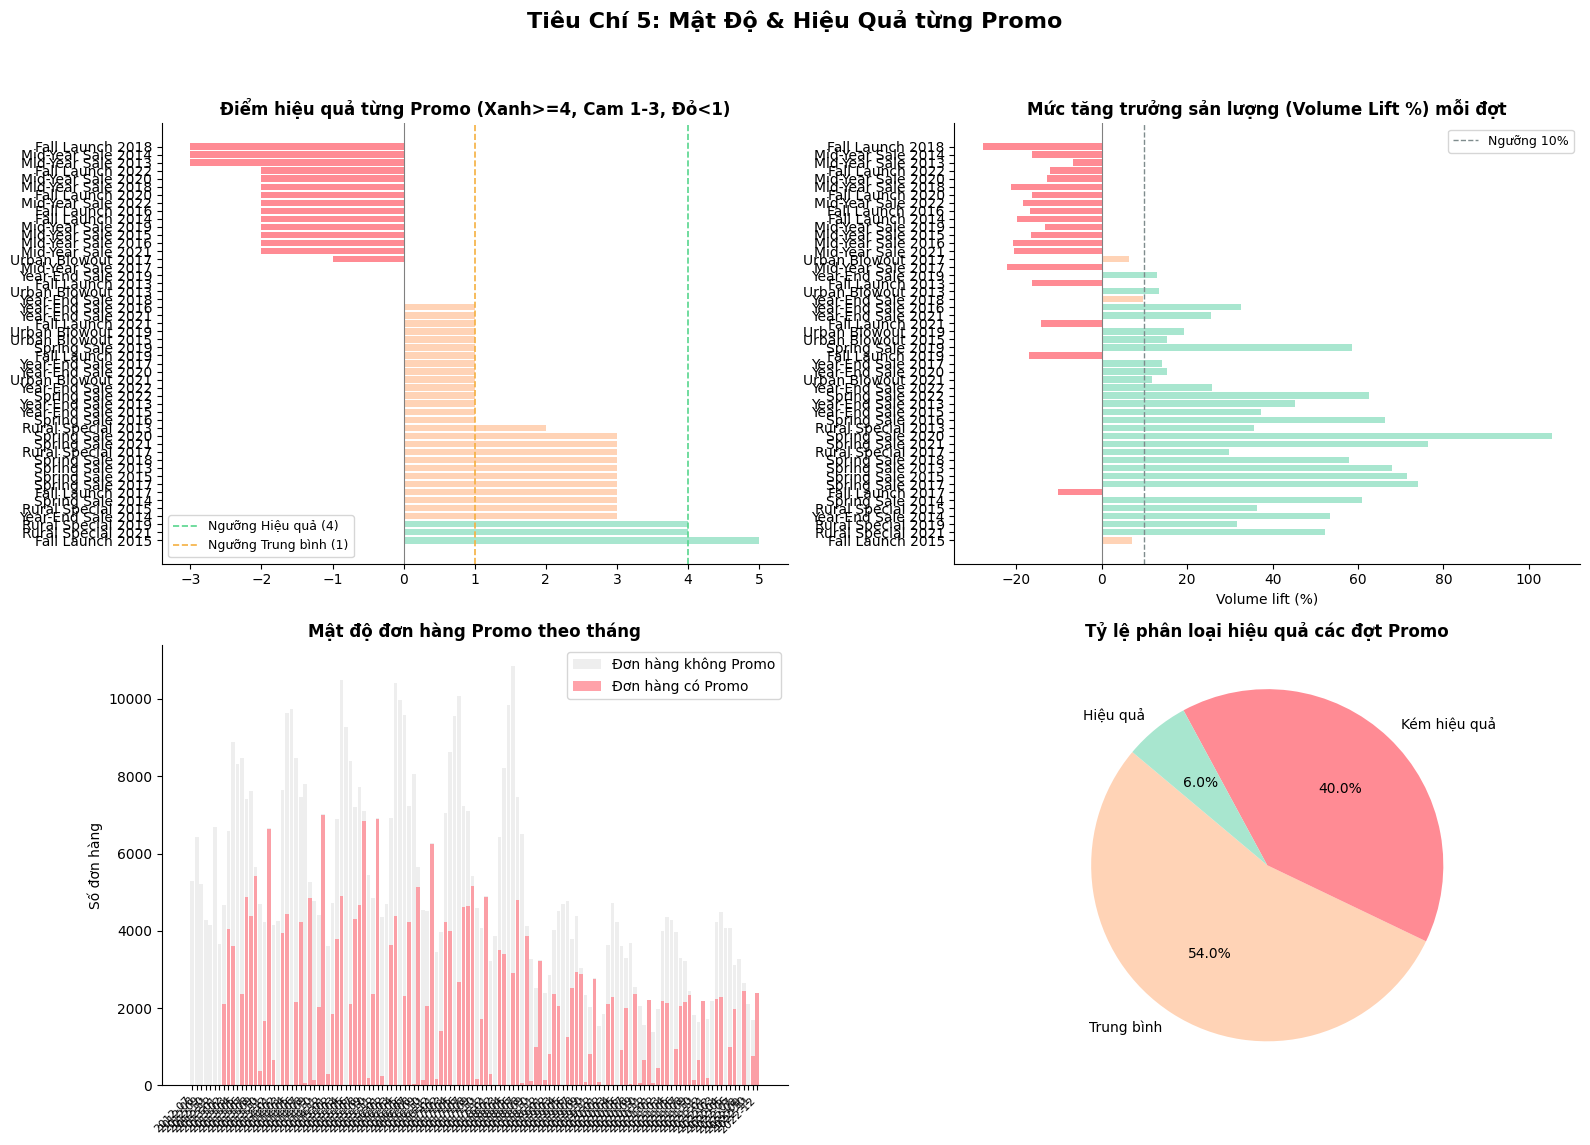


KẾT LUẬN TIÊU CHÍ 5: MẬT ĐỘ & HIỆU QUẢ
[WARN] CẢNH BÁO - Kết quả lẫn lộn: 6% hiệu quả, 40% kém hiệu quả


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Cấu hình màu sắc Pastel ---
# Màu chủ đạo: Xanh lá pastel
color_main = "#A8E6CF" 
# Bảng màu phân loại pastel
color_pass = "#A8E6CF" # Xanh lá pastel
color_warn = "#FFD3B6" # Cam đào pastel
color_fail = "#FF8B94" # Đỏ hồng pastel
color_neutral = "#DCEDC1" # Xanh đậu pastel
color_gray_light = "#EEEEEE" # Xám nhạt

# 1. Chấm điểm từng đợt promo
scores = []
for _, promo in promotions.iterrows():
    s, e = promo["start_date"], promo["end_date"]
    dur  = max((e - s).days + 1, 1)

    # Sales trong đợt promo
    mask = (df["order_date"] >= s) & (df["order_date"] <= e)
    p_df = df[mask]

    # Sales ngoài promo (30 ngày trước)
    mask_b = (df["order_date"] >= s - pd.Timedelta(days=30)) & (df["order_date"] < s)
    b_df   = df[mask_b]
    b_days = 30

    vol_d  = p_df["quantity"].sum()    / dur
    vol_b  = b_df["quantity"].sum()    / b_days if len(b_df)>0 else 0
    rev_d  = p_df["net_revenue"].sum() / dur
    gp_d   = p_df["gross_profit"].sum()/ p_df["net_revenue"].sum() * 100 if p_df["net_revenue"].sum()>0 else 0
    gp_b   = b_df["gross_profit"].sum()/ b_df["net_revenue"].sum() * 100 if len(b_df)>0 and b_df["net_revenue"].sum()>0 else gp_d

    inv_p = inventory[(inventory["snapshot_date"]>=s)&(inventory["snapshot_date"]<=e)]
    inv_b2= inventory[(inventory["snapshot_date"]>=s-pd.Timedelta(days=30))&(inventory["snapshot_date"]<s)]
    ov_d  = inv_p["overstock_flag"].mean() if len(inv_p)>0 else 0
    ov_b2 = inv_b2["overstock_flag"].mean()if len(inv_b2)>0 else ov_d

    vol_lift_p   = (vol_d/vol_b - 1)*100  if vol_b>0 else 0
    gp_change_p  = gp_d - gp_b
    ov_change_p  = (ov_d - ov_b2) * 100

    # Scoring
    score = 0
    score += 2  if vol_lift_p  >  10  else (1 if vol_lift_p>0 else -1)
    score += 2  if gp_change_p > -2   else (-1 if gp_change_p < -5 else 0)
    score += 2  if ov_change_p <  -3  else (-1 if ov_change_p > 3 else 0)

    scores.append({
        "promo_id"    : promo["promo_id"],
        "promo_name"  : promo["promo_name"],
        "start_date"  : s,
        "end_date"    : e,
        "duration_days": dur,
        "vol_lift_%"  : round(vol_lift_p,   2),
        "gp_change_pp": round(gp_change_p,  2),
        "ov_change_pp": round(ov_change_p,  2),
        "score"       : score,
    })

score_df = pd.DataFrame(scores).sort_values("score", ascending=False)
score_df["verdict"] = score_df["score"].apply(
    lambda s: "Hiệu quả" if s>=4 else ("Trung bình" if s>=1 else "Kém hiệu quả")
)

print("=== Xếp hạng hiệu quả từng đợt Promo ===")
print(score_df[["promo_name","duration_days","vol_lift_%",
                "gp_change_pp","ov_change_pp","score","verdict"]].to_string(index=False))

# 2. Xử lý mật độ Promo
df["month_label"] = df["order_date"].dt.to_period("M")
promo_density = (df[df["is_promo"]==True]
                   .groupby("month_label")["order_id"].nunique()
                   .reset_index()
                   .rename(columns={"order_id":"promo_orders"}))
all_orders = df.groupby("month_label")["order_id"].nunique().reset_index().rename(columns={"order_id":"all_orders"})
density = promo_density.merge(all_orders, on="month_label", how="right").fillna(0)
density["promo_share_%"] = density["promo_orders"] / density["all_orders"] * 100

# --- VẼ BIỂU ĐỒ ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Tiêu Chí 5: Mật Độ & Hiệu Quả từng Promo", fontsize=16, fontweight="bold")

# (5a) Điểm hiệu quả từng Promo
score_colors = [color_pass if s>=4 else (color_warn if s>=1 else color_fail) for s in score_df["score"]]
axes[0,0].barh(score_df["promo_name"], score_df["score"], color=score_colors, edgecolor="none")
axes[0,0].axvline(4, color="#58D68D", linestyle="--", linewidth=1.2, label="Ngưỡng Hiệu quả (4)")
axes[0,0].axvline(1, color="#F5B041", linestyle="--", linewidth=1.2, label="Ngưỡng Trung bình (1)")
axes[0,0].axvline(0, color="gray", linewidth=0.8)
axes[0,0].set_title("Điểm hiệu quả từng Promo (Xanh>=4, Cam 1-3, Đỏ<1)", fontweight="bold")
axes[0,0].legend(fontsize=9)

# (5b) Volume Lift %
vl = score_df.set_index("promo_name")["vol_lift_%"]
vl_colors = [color_pass if v>10 else (color_warn if v>0 else color_fail) for v in vl]
axes[0,1].barh(vl.index, vl.values, color=vl_colors, edgecolor="none")
axes[0,1].axvline(0, color="gray", linewidth=0.8)
axes[0,1].axvline(10, color="#7F8C8D", linestyle="--", linewidth=1, label="Ngưỡng 10%")
axes[0,1].set_title("Mức tăng trưởng sản lượng (Volume Lift %) mỗi đợt", fontweight="bold")
axes[0,1].set_xlabel("Volume lift (%)")
axes[0,1].legend(fontsize=9)

# (5c) Mật độ Promo theo tháng
ax5c = axes[1,0]
x5 = range(len(density))
ax5c.bar(x5, density["all_orders"], label="Đơn hàng không Promo", color=color_gray_light, edgecolor="none")
ax5c.bar(x5, density["promo_orders"], label="Đơn hàng có Promo", color=color_fail, alpha=0.8, edgecolor="none")
ax5c.set_xticks(x5)
ax5c.set_xticklabels([str(p) for p in density["month_label"]], rotation=45, ha="right", fontsize=8)
ax5c.set_title("Mật độ đơn hàng Promo theo tháng", fontweight="bold")
ax5c.set_ylabel("Số đơn hàng")
ax5c.legend()

# (5d) Phân loại hiệu quả (Pie Chart)
verdict_cnt = score_df["verdict"].value_counts()
pie_colors_map = {"Hiệu quả": color_pass, "Trung bình": color_warn, "Kém hiệu quả": color_fail}
axes[1,1].pie(verdict_cnt.values, 
              labels=verdict_cnt.index, 
              colors=[pie_colors_map.get(v, color_neutral) for v in verdict_cnt.index],
              autopct="%1.1f%%", startangle=140, 
              wedgeprops=dict(edgecolor="none"))
axes[1,1].set_title("Tỷ lệ phân loại hiệu quả các đợt Promo", fontweight="bold")

# Xóa khung thừa
for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- IN KẾT LUẬN ---
pct_kem = (score_df["verdict"]=="Kém hiệu quả").mean()*100
pct_hq  = (score_df["verdict"]=="Hiệu quả").mean()*100

print("\n" + "=" * 60)
print("KẾT LUẬN TIÊU CHÍ 5: MẬT ĐỘ & HIỆU QUẢ")
print("=" * 60)
if pct_kem >= 50:
    kl5 = f"THẤT BẠI - {pct_kem:.0f}% đợt promo kém hiệu quả, chỉ {pct_hq:.0f}% thực sự hiệu quả"; icon5="[FAIL]"
elif pct_hq >= 50:
    kl5 = f"THÀNH CÔNG - {pct_hq:.0f}% đợt promo đạt hiệu quả tốt"; icon5="[PASS]"
else:
    kl5 = f"CẢNH BÁO - Kết quả lẫn lộn: {pct_hq:.0f}% hiệu quả, {pct_kem:.0f}% kém hiệu quả"; icon5="[WARN]"
print(f"{icon5} {kl5}")

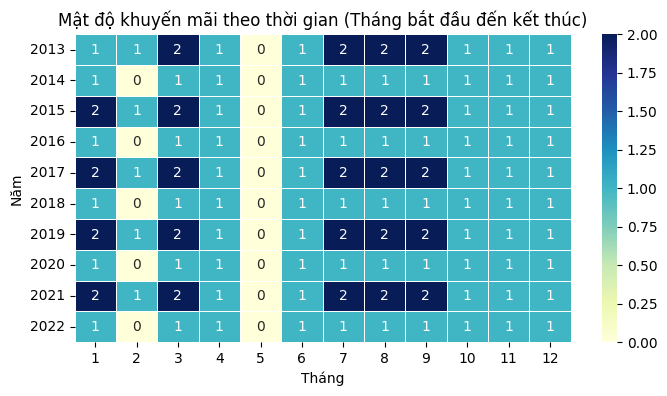

In [ ]:
# Kiểm tra mật độ khuyến mãi theo tháng
# 2. Chuyển đổi cột ngày tháng về đúng định dạng datetime

promotions = pd.read_csv("promotions.csv")
promotions['start_date'] = pd.to_datetime(promotions['start_date'])
promotions['end_date'] = pd.to_datetime(promotions['end_date'])

# 3. Tạo danh sách các tháng mà mỗi khuyến mãi trải qua
promo_months = []

for index, row in promotions.iterrows():
    # Tạo dải thời gian từ tháng bắt đầu đến tháng kết thúc (tần suất tháng 'MS')
    date_range = pd.date_range(start=row['start_date'].replace(day=1), 
                               end=row['end_date'], 
                               freq='MS')
    for date in date_range:
        promo_months.append({'Year': date.year, 'Month': date.month})

# 4. Tạo DataFrame mới từ danh sách đã trải phẳng
df_heatmap = pd.DataFrame(promo_months)

# 5. Tạo bảng Pivot để đếm số lượng khuyến mãi mỗi tháng
pivot_table = df_heatmap.pivot_table(index='Year', 
                                     columns='Month', 
                                     aggfunc='size', 
                                     fill_value=0)

# 6. Đảm bảo đủ 12 tháng trên trục X (từ tháng 1 đến 12)
for m in range(1, 13):
    if m not in pivot_table.columns:
        pivot_table[m] = 0
pivot_table = pivot_table.reindex(columns=sorted(pivot_table.columns))

# 7. Vẽ biểu đồ
plt.figure(figsize=(8, 4))
sns.heatmap(pivot_table, annot=True, fmt="d", cmap="YlGnBu", linewidths=.5)
plt.title('Mật độ khuyến mãi theo thời gian (Tháng bắt đầu đến kết thúc)')
plt.xlabel('Tháng')
plt.ylabel('Năm')
plt.show()

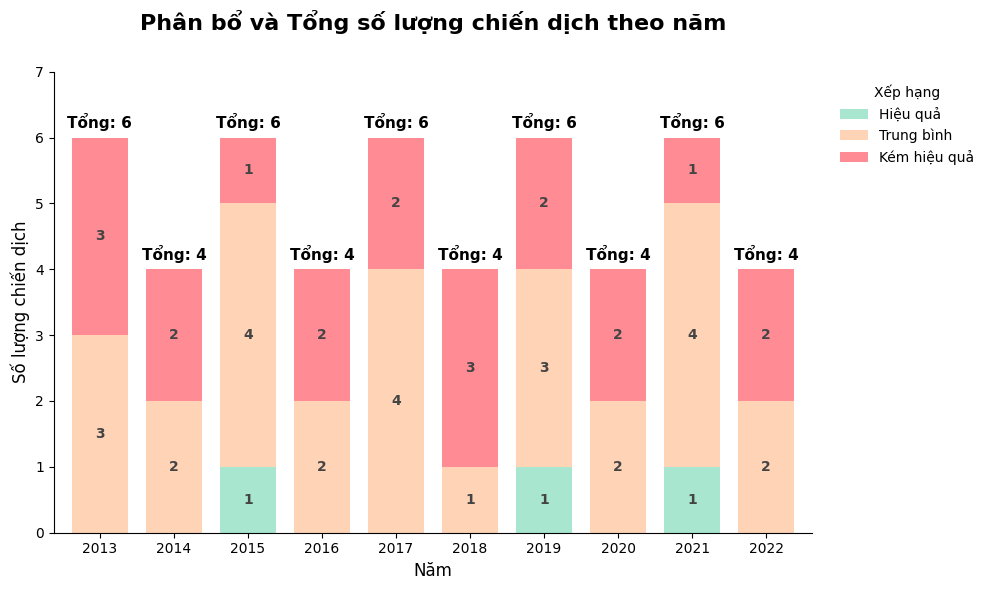

In [ ]:
# 1. Trích xuất năm và tạo bảng pivot
score_df["year"] = score_df["start_date"].dt.year
yearly_verdict = score_df.groupby(["year", "verdict"]).size().unstack(fill_value=0)

# Sắp xếp thứ tự: Hiệu quả -> Trung bình -> Kém hiệu quả
ordered_cols = [c for c in ["Hiệu quả", "Trung bình", "Kém hiệu quả"] if c in yearly_verdict.columns]
yearly_verdict = yearly_verdict[ordered_cols]

# Tính tổng số chiến dịch của mỗi năm để đặt lên đầu cột
totals = yearly_verdict.sum(axis=1)

# 2. Vẽ biểu đồ
ax = yearly_verdict.plot(kind='bar', stacked=True, figsize=(10, 6),
                         color=[color_pass, color_warn, color_fail], 
                         edgecolor='none', width=0.75)

# --- BỔ SUNG VALUE CHO TỪNG PHÂN ĐOẠN ---
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        x, y = p.get_xy() 
        ax.text(x + p.get_width()/2, y + height/2, f'{int(height)}', 
                ha='center', va='center', fontsize=10, fontweight='bold', color='#444444')

# --- BỔ SUNG TỔNG (TOTAL) TRÊN ĐẦU MỖI CỘT ---
for i, total in enumerate(totals):
    ax.text(i, total + 0.1, f'Tổng: {int(total)}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

# 3. Tinh chỉnh giao diện
plt.title("Phân bổ và Tổng số lượng chiến dịch theo năm", fontweight="bold", fontsize=16, pad=30)
plt.xlabel("Năm", fontsize=12)
plt.ylabel("Số lượng chiến dịch", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Xếp hạng", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

# Giới hạn trục y cao hơn một chút để không bị đè chữ "Tổng"
plt.ylim(0, totals.max() + 1)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

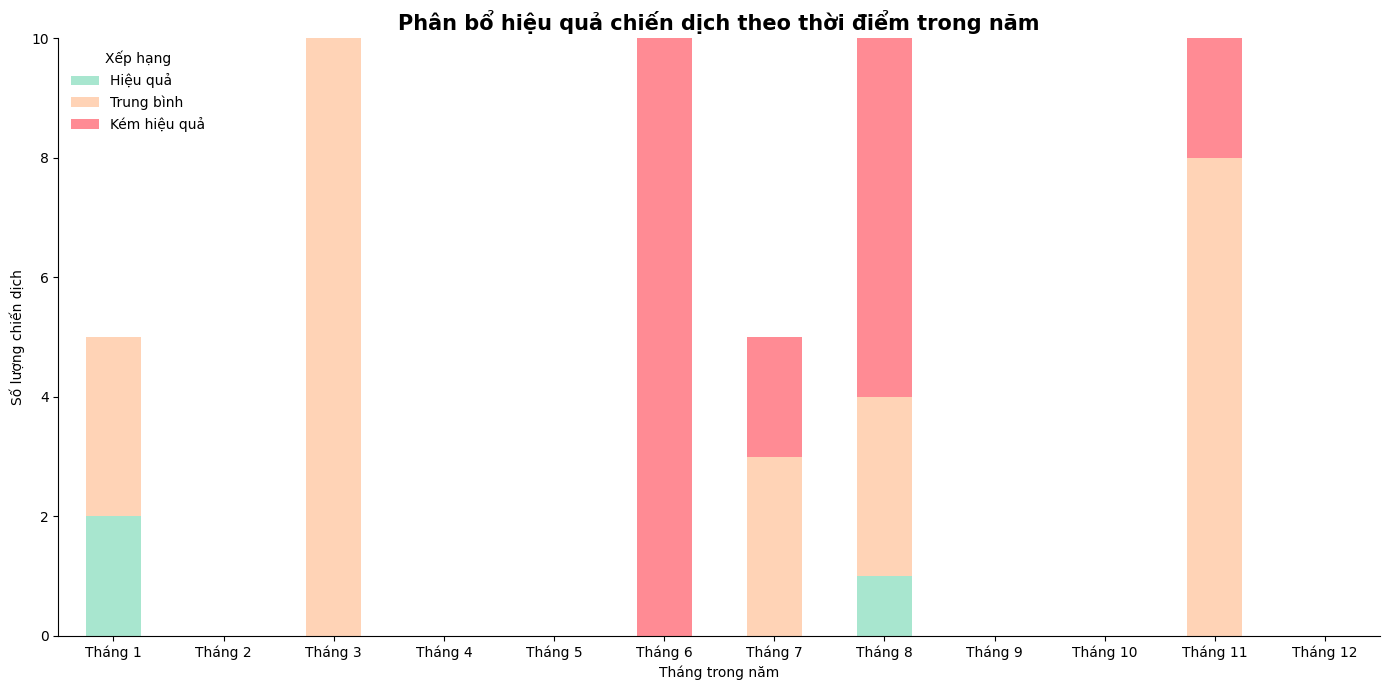

PHÂN TÍCH TÍNH CHU KỲ:
- Các tháng giữa năm (Tháng 5 - Tháng 8): Tập trung dày đặc các chiến dịch 'Kém hiệu quả', chủ yếu là Mid-Year Sale.
- Các tháng cuối năm (Tháng 11 - Tháng 12): Số lượng chiến dịch 'Trung bình' chiếm đa số, cho thấy việc đẩy doanh số cao nhưng lợi nhuận thấp.
- Các chiến dịch 'Hiệu quả' thực sự rất ít và rải rác, cần nghiên cứu kỹ hơn về cơ cấu giá của các đợt này.


In [ ]:
# 1. Chuẩn bị dữ liệu phân bổ theo tháng và loại hiệu quả
score_df['month'] = score_df['start_date'].dt.month
dist_data = score_df.groupby(['month', 'verdict']).size().unstack(fill_value=0)

# Đảm bảo có đủ 12 tháng và đúng thứ tự phân loại
dist_data = dist_data.reindex(range(1, 13), fill_value=0)
order = ["Hiệu quả", "Trung bình", "Kém hiệu quả"]
dist_data = dist_data[[c for c in order if c in dist_data.columns]]

# 2. Vẽ biểu đồ Stacked Bar
plt.figure(figsize=(14, 7))
ax = dist_data.plot(kind='bar', stacked=True, 
                    color=[color_pass, color_warn, color_fail], 
                    ax=plt.gca(), edgecolor='none')

# 3. Tinh chỉnh giao diện theo tông Pastel
plt.title("Phân bổ hiệu quả chiến dịch theo thời điểm trong năm", fontweight="bold", fontsize=15)
plt.xlabel("Tháng trong năm")
plt.ylabel("Số lượng chiến dịch")
plt.xticks(range(0, 12), [f"Tháng {m}" for m in range(1, 13)], rotation=0)
plt.legend(title="Xếp hạng", frameon=False)

# Xóa khung thừa
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# --- NHẬN XÉT CHIẾN THUẬT ---
print("PHÂN TÍCH TÍNH CHU KỲ:")
print("- Các tháng giữa năm (Tháng 5 - Tháng 8): Tập trung dày đặc các chiến dịch 'Kém hiệu quả', chủ yếu là Mid-Year Sale.")
print("- Các tháng cuối năm (Tháng 11 - Tháng 12): Số lượng chiến dịch 'Trung bình' chiếm đa số, cho thấy việc đẩy doanh số cao nhưng lợi nhuận thấp.")
print("- Các chiến dịch 'Hiệu quả' thực sự rất ít và rải rác, cần nghiên cứu kỹ hơn về cơ cấu giá của các đợt này.")